# Dendros Quickstart

This notebook demonstrates the main workflows of the **`dendros`** library
for reading and exploring [Galacticus](https://github.com/galacticusorg/galacticus)
HDF5 output files.

We begin by creating a small synthetic HDF5 file that mimics the Galacticus
output structure, so you can run this notebook without needing a real
Galacticus run.

In [1]:
import tempfile
from pathlib import Path

import h5py
import numpy as np

# -----------------------------------------------------------------------
# Create a minimal synthetic Galacticus-like HDF5 file
# -----------------------------------------------------------------------

tmpdir = tempfile.mkdtemp()
fpath = str(Path(tmpdir) / "galacticus.hdf5")

rng = np.random.default_rng(42)
N1, N2, N3 = 500, 300, 150  # galaxy counts for three snapshots

# Galaxy IDs (nodeUniqueIDBranchTip) overlap between snapshots so histories
# can be traced.  Output1 is the latest (z=0).
ids_1 = np.arange(N1, dtype=np.int64)
ids_2 = np.arange(N2, dtype=np.int64)           # first N2 survivors from O1
ids_3 = np.arange(N3, dtype=np.int64)           # first N3 survivors from O2

with h5py.File(fpath, "w") as f:
    f.attrs["statusCompletion"] = 0

    outputs = f.create_group("Outputs")

    def _write(grp_name, t, a, ids, N):
        grp = outputs.create_group(grp_name)
        grp.attrs["outputTime"] = t
        grp.attrs["outputExpansionFactor"] = a
        nd = grp.create_group("nodeData")
        nd.create_dataset("nodeUniqueIDBranchTip", data=ids)
        ds = nd.create_dataset("basicMass", data=rng.lognormal(26.0, 1.0, N))
        ds.attrs["comment"] = "Virial mass of the halo"
        ds.attrs["unitsInSI"] = 1.989e30
        ds = nd.create_dataset("diskMassStellar", data=rng.lognormal(23.0, 1.0, N))
        ds.attrs["comment"] = "Disk stellar mass"
        ds.attrs["unitsInSI"] = 1.989e30
        ds = nd.create_dataset("diskRadius", data=rng.lognormal(-3.0, 0.5, N))
        ds.attrs["comment"] = "Half-mass radius of the disk"
        ds.attrs["unitsInSI"] = 3.086e22

    # Output1 (z=0), Output2 (z=1), Output3 (z~3) — ordered by increasing
    # index but decreasing scale factor, matching Galacticus convention.
    _write("Output1", 13.8, 1.0, ids_1, N1)
    _write("Output2",  5.9, 0.5, ids_2, N2)
    _write("Output3",  2.1, 0.25, ids_3, N3)

print(f"Synthetic file written to: {fpath}")


Synthetic file written to: /tmp/tmpy8j246m9/galacticus.hdf5


## Opening a file

In [2]:
import sys
import os
try:
    notebook_path = __session__
except NameError:
    # Fallback to environment variable
    notebook_path = os.environ.get("JPY_SESSION_NAME")
module_path = os.path.abspath(os.path.dirname(notebook_path) + '/../src')
if module_path not in sys.path:
    sys.path.insert(0,module_path)

In [3]:
from dendros import open_outputs
c = open_outputs(fpath)
print(c)

<Collection files=1 output_root='Outputs' path='/tmp/tmpy8j246m9/galacticus.hdf5'>


## Checking completion status

In [4]:
c.validate_completion()  # raises RuntimeError if the run did not complete
print("Run completed successfully.")

Run completed successfully.


## Listing outputs

`list_outputs()` returns an `astropy.table.Table` (default), a
`pandas.DataFrame` or a `tabulate` string with time, scale factor, and redshift for each snapshot.

In [5]:
tbl = c.list_outputs()
print(tbl)

index   name  time scale_factor redshift
----- ------- ---- ------------ --------
    1 Output1 13.8          1.0      0.0
    2 Output2  5.9          0.5      1.0
    3 Output3  2.1         0.25      3.0


In [6]:
# Access individual output metadata
for meta in c.outputs:
    print(f"{meta.name}: z = {meta.redshift:.3f}, t = {meta.time:.2f} Gyr")

Output1: z = 0.000, t = 13.80 Gyr
Output2: z = 1.000, t = 5.90 Gyr
Output3: z = 3.000, t = 2.10 Gyr


## Listing properties

`list_properties()` shows the datasets available in the `nodeData` group,
together with their description and SI conversion factor.

In [7]:
props = c.list_properties("Output1",format="tabulate")
print(props)

    name                   dtype    shape    description                unitsInSI
--  ---------------------  -------  -------  -----------------------  -----------
 0  basicMass              float64  (500,)   Virial mass of the halo    1.989e+30
 1  diskMassStellar        float64  (500,)   Disk stellar mass          1.989e+30
 2  diskRadius             float64  (500,)   Half-mass radius of the    3.086e+22
                                             disk
 3  nodeUniqueIDBranchTip  int64    (500,)                              1


## Reading datasets

In [8]:
# Read by dataset path — same string used as dict key
data = c.read("Output1", ["nodeData/basicMass", "nodeData/diskMassStellar"])
print("basicMass shape:", data["nodeData/basicMass"].shape)

# Or use a dict for custom labels
data = c.read(
    "Output1",
    {"Mhalo": "nodeData/basicMass", "Mstar": "nodeData/diskMassStellar"},
)
print("Mhalo[:5] =", data["Mhalo"][:5])

basicMass shape: (500,)
Mhalo[:5] = [2.65456568e+11 6.91826464e+10 4.14546586e+11 5.01347202e+11
 2.78184362e+10]


## Filtering galaxies

Pass a boolean mask or integer index array as `where`.

In [9]:
all_data = c.read("Output1", {"Mhalo": "nodeData/basicMass"})
massive = all_data["Mhalo"] > 1.0e12

filtered = c.read(
    "Output1",
    {"Mhalo": "nodeData/basicMass", "Mstar": "nodeData/diskMassStellar"},
    where=massive,
)
print(f"Selected {massive.sum()} of {len(all_data['Mhalo'])} galaxies")

Selected 24 of 500 galaxies


## h5py-like browsing

In [10]:
print("Top-level keys:", c.keys())

grp = c["Outputs/Output1"]
print("Output1 attrs:", grp.attrs)
print("Output1 keys:", grp.keys())

ds = c["Outputs/Output1/nodeData/basicMass"]
print(f"haloMass dtype={ds.dtype}  shape={ds.shape}")

Top-level keys: ['Outputs']
Output1 attrs: {'outputExpansionFactor': '1.0', 'outputTime': '13.8'}
Output1 keys: ['nodeData']
haloMass dtype=float64  shape=(500,)


## Tracing galaxy histories

`nodeUniqueIDBranchTip` uniquely identifies a galaxy within a file and is
constant across outputs, so `trace_history` can assemble per-galaxy time
series from all snapshots in a single call. The returned arrays have an
extra trailing axis indexing time; slots where the galaxy was absent are
filled with `NaN` (floats), `int_sentinel` (ints), or `False` (bools), and
a companion `present` mask is returned as the canonical indicator of
presence.

In [11]:
ids = [0, 150, 300]   # a galaxy that survives to z=0, one that merges before z=1,
                      # and one that only exists in the earliest snapshot
hist = c.trace_history(
    ids,
    {"Mhalo": "nodeData/basicMass", "Mstar": "nodeData/diskMassStellar"},
)

print("outputs:", hist["output_names"].tolist())
print("present mask:\n", hist["present"])
print("Mstar shape:", hist["Mstar"].shape)
print("time shape :", hist["time"].shape)

outputs: ['Output1', 'Output2', 'Output3']
present mask:
 [[ True  True  True]
 [ True  True False]
 [ True False False]]
Mstar shape: (3, 3)
time shape : (3, 3)


Use the `present` mask to drop absent slots before plotting or arithmetic:

In [12]:
for i, gid in enumerate(ids):
    mask = hist["present"][i]
    t     = hist["time"][i][mask]
    mstar = hist["Mstar"][i][mask]
    print(f"id={gid}: present at {mask.sum()} / {mask.size} outputs; Mstar = {mstar}")

id=0: present at 3 / 3 outputs; Mstar = [3.81145612e+10 9.36545463e+09 1.81779410e+09]
id=150: present at 2 / 3 outputs; Mstar = [6.18405424e+10 1.03103241e+10]
id=300: present at 1 / 3 outputs; Mstar = [4.18576229e+09]


## Multi-file (MPI) example

Create two synthetic MPI-split files and open them together.

In [13]:
mpi0 = str(Path(tmpdir) / "galacticus_MPI:0000.hdf5")
mpi1 = str(Path(tmpdir) / "galacticus_MPI:0001.hdf5")

for rank, path in enumerate([mpi0, mpi1]):
    with h5py.File(path, "w") as f:
        f.attrs["statusCompletion"] = 0
        grp = f.create_group("Outputs/Output1")
        grp.attrs["outputTime"] = 13.8
        grp.attrs["outputExpansionFactor"] = 1.0
        nd = grp.create_group("nodeData")
        start = rank * 250
        ds = nd.create_dataset("basicMass", data=rng.lognormal(26.0, 1.0, 250))
        ds.attrs["comment"] = "Virial mass of the halo"
        ds.attrs["unitsInSI"] = 1.989e30

# open_outputs auto-detects the peer file from any single rank
with open_outputs(mpi0) as mc:
    print("Files in collection:", mc.files)
    data = mc.read("Output1", ["nodeData/basicMass"])
    print("Total galaxies from both ranks:", len(data["nodeData/basicMass"]))

Files in collection: ['/tmp/tmpy8j246m9/galacticus_MPI:0000.hdf5']
Total galaxies from both ranks: 250


## Plotting analyses

If a Galacticus run was configured to write reduced analysis results, the
output file will contain a top-level `/analyses` group with one subgroup
per analysis. Each subgroup stores the model curve, optional observational
target data, and metadata (axis labels, log/linear scaling, error bars).

Dendros can tabulate every `function1D` analysis with `list_analyses`, and
plot the model curve and target overlay with `plot_analyses` — requires
the `[plot]` extra (`pip install 'dendros[plot]'`). For MPI runs the data
in `/analyses` is reduced over all ranks and is identical in every file,
so dendros reads only the primary file.

Below we synthesize a tiny analyses file (a stellar mass function with a
mock observational comparison) to demonstrate the API.

In [14]:
analyses_path = str(Path(tmpdir) / "analyses_demo.hdf5")

with h5py.File(analyses_path, "w") as f:
    f.attrs["statusCompletion"] = 0
    # An empty Outputs group keeps the file shaped like a real run.
    f.create_group("Outputs/Output1").attrs["outputTime"] = 13.8

    grp = f.create_group("analyses").create_group("stellarMassFunction")
    grp.attrs["type"]         = np.bytes_("function1D")
    grp.attrs["description"]  = np.bytes_(r"Stellar mass function at $z=0$")
    grp.attrs["xAxisLabel"]   = np.bytes_(r"$M_\star\,/\,M_\odot$")
    grp.attrs["yAxisLabel"]   = np.bytes_(r"$\phi\,/\,\hbox{Mpc}^{-3}\,\hbox{dex}^{-1}$")
    grp.attrs["xAxisIsLog"]   = np.int32(1)
    grp.attrs["yAxisIsLog"]   = np.int32(1)
    grp.attrs["targetLabel"]  = np.bytes_("Bernardi+13 (mock)")

    # Schechter-like model curve.
    x = np.logspace(8.0, 12.0, 16)
    phi_star, M_star, alpha = 1e-2, 1e11, -1.2
    y = (phi_star * (x / M_star) ** (alpha + 1)
         * np.exp(-x / M_star) / np.log(10.0))

    grp.create_dataset("x", data=x);  grp.attrs["xDataset"] = np.bytes_("x")
    grp.create_dataset("y", data=y);  grp.attrs["yDataset"] = np.bytes_("y")
    grp.create_dataset("yErrorLower", data=y * 0.7)
    grp.create_dataset("yErrorUpper", data=y * 1.3)
    grp.attrs["yErrorLower"] = np.bytes_("yErrorLower")
    grp.attrs["yErrorUpper"] = np.bytes_("yErrorUpper")

    # Mock observational target with scatter + asymmetric errors.
    yt = y * np.exp(0.07 * rng.standard_normal(len(x)))
    grp.create_dataset("yTarget", data=yt)
    grp.attrs["yDatasetTarget"] = np.bytes_("yTarget")
    grp.create_dataset("yErrorLowerTarget", data=yt * 0.75)
    grp.create_dataset("yErrorUpperTarget", data=yt * 1.30)
    grp.attrs["yErrorLowerTarget"] = np.bytes_("yErrorLowerTarget")
    grp.attrs["yErrorUpperTarget"] = np.bytes_("yErrorUpperTarget")

print(f"Synthetic analyses file: {analyses_path}")

Synthetic analyses file: /tmp/tmpy8j246m9/analyses_demo.hdf5


In [15]:
with open_outputs(analyses_path) as ac:
    print(ac.list_analyses())

        name                 description           ... yAxisIsLog hasTarget
------------------- ------------------------------ ... ---------- ---------
stellarMassFunction Stellar mass function at $z=0$ ...       True      True


`plot_analyses` returns a `dict[str, matplotlib.figure.Figure]`, so the
figures display inline in a Jupyter notebook. Pass `output_directory=` to
also save them to disk, or `name=` to plot a specific analysis.

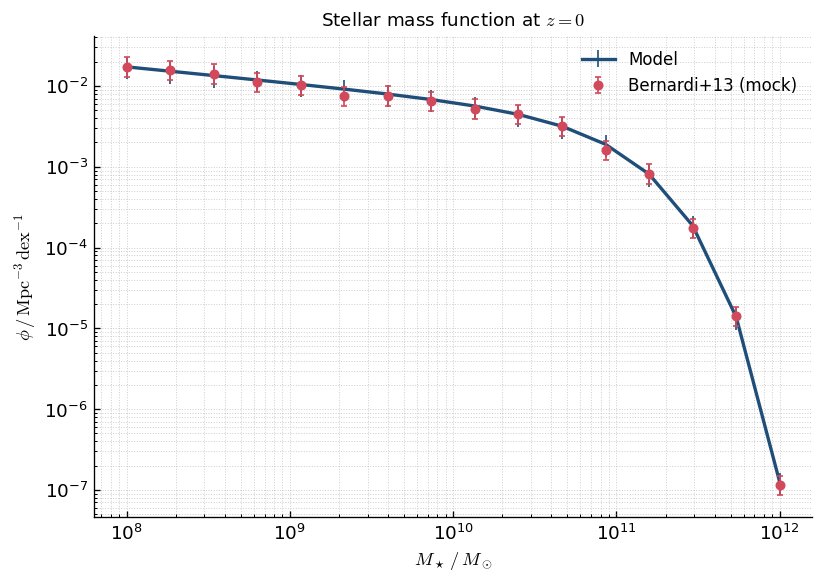

In [16]:
with open_outputs(analyses_path) as ac:
    figs = ac.plot_analyses()

figs["stellarMassFunction"]

## Clean up

In [17]:
c.close()
import shutil
shutil.rmtree(tmpdir)
print("Done.")

Done.
